In [80]:
import numpy as np
import scipy.constants
import scipy.sparse
from scipy.stats import norm
import matplotlib.pyplot as plt
import xarray as xr
import math
import geopandas as gpd
import pandas as pd
import os
import netCDF4 as nc

In [58]:
def calc_alongshore_transport_k(gravity=scipy.constants.g, n=1.0, rho_water=1050.0, gamma_b=0.78, ):
    return (
        5.3e-6
        # * 0.46
        * rho_water
        * gravity**1.5
        * (1 / (2 * n)) ** 1.2
        * (np.sqrt(gravity * gamma_b) / (2 * np.pi)) ** 0.2
    )

In [48]:
def get_angles(gdf): # input gdf with centroids
    bearings = []
    bearings.append(0) # stupid fix so dimensions match. added 0 to either end of the coastline. theres a better way to do this probably. :/
    for i in range(len(gdf['centroid'].values)-2):
        lat1 = math.radians(coast_transects['lat_avg'][i])
        lon1 = math.radians(coast_transects['lon_avg'][i])
        lat2 = math.radians(coast_transects['lat_avg'][i+2])
        lon2 = math.radians(coast_transects['lon_avg'][i+2])
        dlon = lon2-lon1
        y = math.sin(dlon) * math.cos(lat2)
        x = math.cos(lat1) * math.sin(lat2) - math.sin(lat1) * math.cos(lat2) * math.cos(dlon)
        bearing = math.atan2(y, x)
        bearing = math.degrees(bearing)
        bearing = (bearing + 360) % 360
        bearings.append(bearing)
    bearings.append(0) 
    return bearings

In [49]:
def calc_diff(dm, hs, tp, angles, k, d=8): # mean direction of propagation bearing from north (degrees), significant wave height (meters), period (seconds), k, d (meters) 

    # change to data array just in case
    tp_da = tp['tp'] if isinstance(tp, xr.Dataset) else tp
    hs_da = hs['hs'] if isinstance(hs, xr.Dataset) else hs
    dm_da = dm['dm'] if isinstance(dm, xr.Dataset) else dm

    # change angles to phi/theta and compute diffusivity 
    phi = (dm_da + 90) % 360
    thet = angles
    angle_term = np.minimum(np.abs((phi - thet) % 360), np.abs((phi - ((thet - 180) % 360))))
    angle_term = angle_term.where(angle_term <= 90)
    rad_factor = np.pi / 180
    angle_term = angle_term * rad_factor
    cos_term = np.cos(angle_term)
    sin_term = np.sin(angle_term)
    coeff = k / d
    power_term = ((tp_da * cos_term) ** 0.2) * (hs_da ** 2.4) 
    diff = -(coeff * power_term * ((1.2 * (sin_term**2)) - (cos_term**2)))
    return diff

In [50]:
# open dataset
dm = xr.open_dataset('dm_NorthCarolina.nc')
hs = xr.open_dataset('hs_NorthCarolina.nc')
tp = xr.open_dataset('tp_NorthCarolina.nc')
coast_transects = gpd.read_file('NC_transects.geojson')

In [51]:
# find mean lat lon for each transect through time
coast_transects['centroid'] = coast_transects.geometry.centroid
coast_transects['lon_avg'] = coast_transects.centroid.x
coast_transects['lat_avg'] = coast_transects.centroid.y

/tmp/ipykernel_1980515/3940127040.py:2: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  coast_transects['centroid'] = coast_transects.geometry.centroid
/tmp/ipykernel_1980515/3940127040.py:3: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  coast_transects['lon_avg'] = coast_transects.centroid.x
/tmp/ipykernel_1980515/3940127040.py:4: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  coast_transects['lat_avg'] = coast_transects.centroid.y


<Axes: >

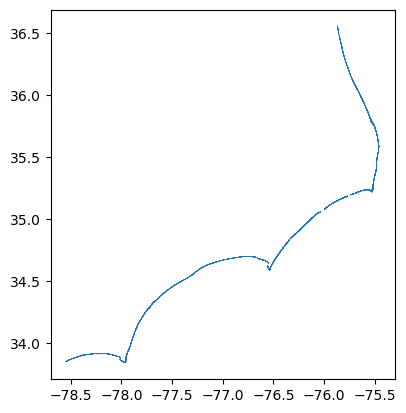

In [52]:
# double check centroids
coast_transects.plot()

In [53]:
# compute shoreline angles (bearing from north)
raw_angles = get_angles(coast_transects)

In [54]:
# compute k constant
k = calc_alongshore_transport_k()

In [55]:
# extends and maps wave data to nearest transect centroid
wave_lats = dm.lat.values
wave_lons = dm.lon.values
transect_lats = coast_transects['lat_avg'].values
transect_lons = coast_transects['lon_avg'].values

def get_nearest_indices(w_lats, w_lons, t_lats, t_lons):
    indices = []
    for lat, lon in zip(t_lats, t_lons):
        dist = np.sqrt((w_lats - lat)**2 + (w_lons - lon)**2)
        indices.append(np.argmin(dist))
    return np.array(indices)

mapping_idx = get_nearest_indices(wave_lats, wave_lons, transect_lats, transect_lons)

dm_mapped = dm.isel(site=mapping_idx)
hs_mapped = hs.isel(site=mapping_idx)
tp_mapped = tp.isel(site=mapping_idx)

angles_xr = xr.DataArray(
    raw_angles, 
    dims=['site'],
    name='shoreline_angle'
)

In [56]:
# tried chunks, didnt work
# dm_chunk = dm_mapped.chunk({'time': 50000})
# hs_chunk = hs_mapped.chunk({'time': 50000})
# tp_chunk = tp_mapped.chunk({'time': 50000})

# diff_array = calc_diff(dm_chunk, hs_chunk, tp_chunk, angles_xr, k)

In [57]:
# iteratively save nc file
file_name = 'ncdiffusion_perday_pertransect.nc'
if os.path.exists(file_name):
    os.remove(file_name)

total_time_len = len(dm_mapped.time)

full_template = xr.Dataset(
    {"diffusivity": (("time", "site"), np.zeros((total_time_len, len(angles_xr)), dtype='float32'))},
    coords={"time": dm_mapped.time, "site": dm_mapped.site}
)

full_template.to_netcdf(file_name) 

with nc.Dataset(file_name, 'a') as dst:
    step = 50000
    for i in range(0, total_time_len, step):
        end_idx = min(i + step, total_time_len)
        print(f"Writing indices: {i} to {end_idx}...")
        
        dm_slice = dm_mapped.isel(time=slice(i, end_idx))
        hs_slice = hs_mapped.isel(time=slice(i, end_idx))
        tp_slice = tp_mapped.isel(time=slice(i, end_idx))
        
        diff_slice = calc_diff(dm_slice, hs_slice, tp_slice, angles_xr, k)

        dst['diffusivity'][i:end_idx, :] = diff_slice.values

print(f"Saved as {file_name}")

Writing indices: 0 to 50000...
Writing indices: 50000 to 100000...
Writing indices: 100000 to 150000...
Writing indices: 150000 to 200000...
Writing indices: 200000 to 250000...
Writing indices: 250000 to 300000...
Writing indices: 300000 to 350000...
Writing indices: 350000 to 385714...
Saved as ncdiffusion_perday_pertransect.nc


**Troubleshooting**

In [73]:
# compute and plot all variables for one time slice (plots are all on centroids, not exact transect values)
target_date = "2013-01-15 12:00" 
# rad_factor = np.pi / 180
dm_snapshot = dm_mapped.sel(time=target_date, method='nearest')
phi = ((dm_snapshot) + 90 + 360) % 360
thet = angles_xr
angle_snapshot = np.minimum(np.abs((phi - thet) % 360), np.abs((phi - ((thet - 180) % 360))))
angle_snapshot = angle_snapshot.where(angle_snapshot <= 90)
hs_snapshot = hs_mapped.sel(time=target_date, method='nearest')
tp_snapshot = tp_mapped.sel(time=target_date, method='nearest')

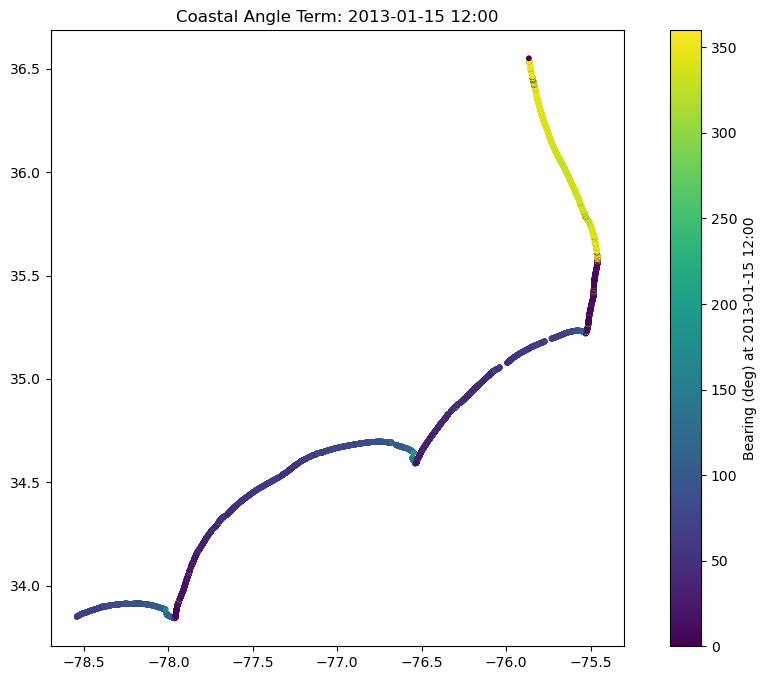

In [74]:
extracted_array = angles_xr 

coast_transects['snapshot_val'] = extracted_array.values.astype(float)

fig, ax = plt.subplots(figsize=(12, 8))

plot = coast_transects.set_geometry('centroid').plot(
    column='snapshot_val',
    cmap='viridis',
    legend=False, 
    markersize=10,
    ax=ax
)
 
vmin = coast_transects['snapshot_val'].min() 
vmax = coast_transects['snapshot_val'].max()

sm = plt.cm.ScalarMappable(
    cmap='viridis', 
    norm=plt.Normalize(vmin=vmin, vmax=vmax)
)

cbar = fig.colorbar(sm, ax=ax)
cbar.set_label(f"Bearing (deg) at {target_date}")

ax.set_title(f"Coastal Angle Term: {target_date}")
plt.show()

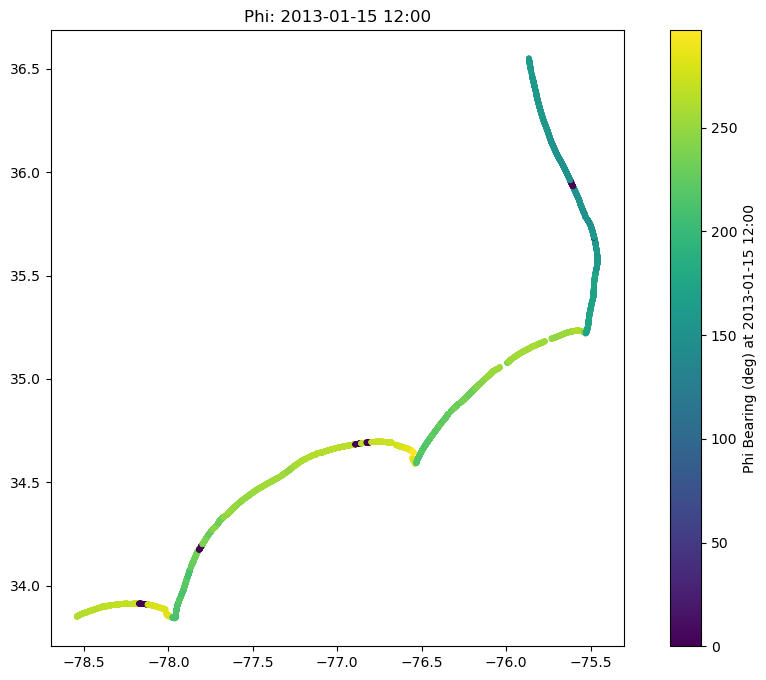

In [75]:
extracted_array = phi['dm'] 

coast_transects['snapshot_val'] = extracted_array.values.astype(float)

fig, ax = plt.subplots(figsize=(12, 8))

plot = coast_transects.set_geometry('centroid').plot(
    column='snapshot_val',
    cmap='viridis',
    legend=False, 
    markersize=10,
    ax=ax
)
 
vmin = coast_transects['snapshot_val'].min() 
vmax = coast_transects['snapshot_val'].max()

sm = plt.cm.ScalarMappable(
    cmap='viridis', 
    norm=plt.Normalize(vmin=vmin, vmax=vmax)
)

cbar = fig.colorbar(sm, ax=ax)
cbar.set_label(f"Phi Bearing (deg) at {target_date}")

ax.set_title(f"Phi: {target_date}")
plt.show()

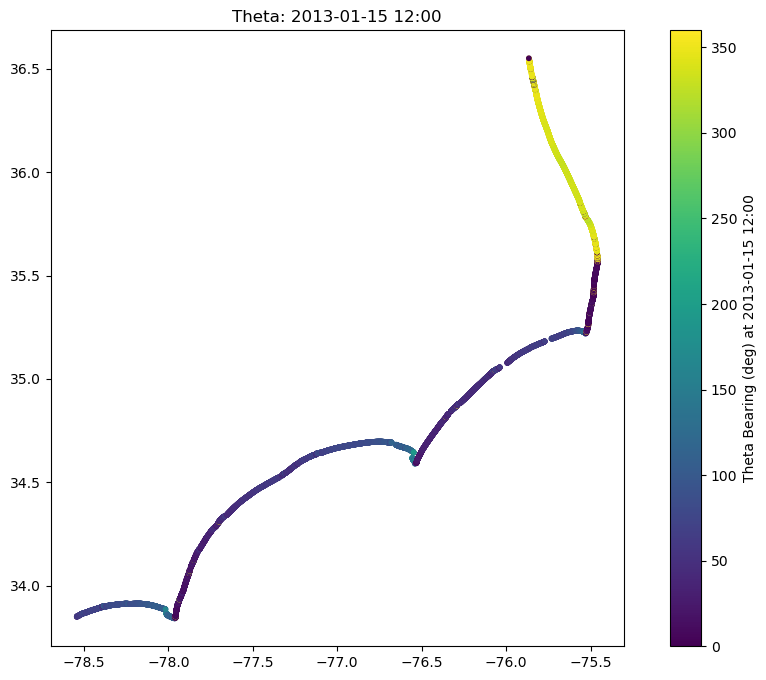

In [76]:
extracted_array = thet

coast_transects['snapshot_val'] = extracted_array.values.astype(float)

fig, ax = plt.subplots(figsize=(12, 8))

plot = coast_transects.set_geometry('centroid').plot(
    column='snapshot_val',
    cmap='viridis',
    legend=False, 
    markersize=10,
    ax=ax
)
 
vmin = coast_transects['snapshot_val'].min() 
vmax = coast_transects['snapshot_val'].max()

sm = plt.cm.ScalarMappable(
    cmap='viridis', 
    norm=plt.Normalize(vmin=vmin, vmax=vmax)
)

cbar = fig.colorbar(sm, ax=ax)
cbar.set_label(f"Theta Bearing (deg) at {target_date}")

ax.set_title(f"Theta: {target_date}")
plt.show()

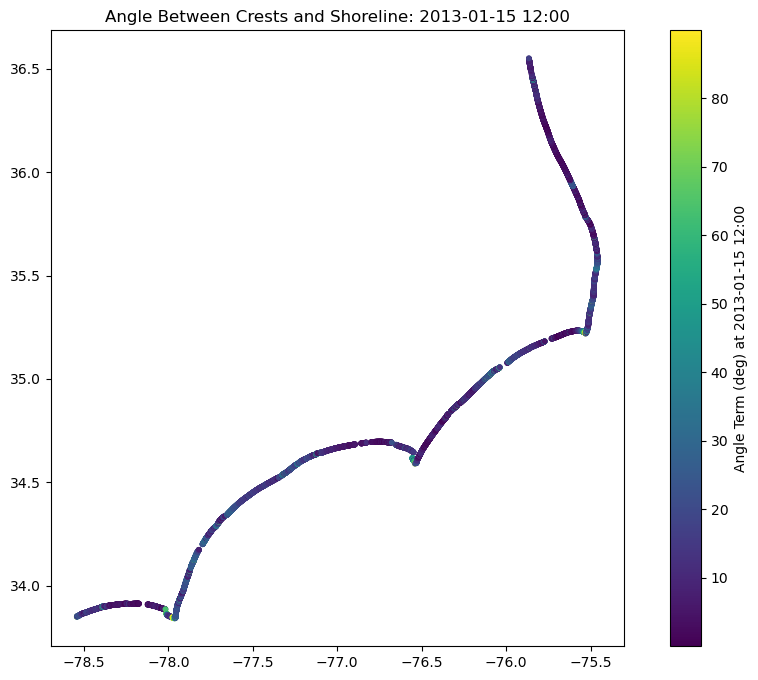

In [77]:
extracted_array = angle_snapshot['dm'] 

coast_transects['snapshot_val'] = extracted_array.values.astype(float)

fig, ax = plt.subplots(figsize=(12, 8))

plot = coast_transects.set_geometry('centroid').plot(
    column='snapshot_val',
    cmap='viridis',
    legend=False, 
    markersize=10,
    ax=ax
)
 
vmin = coast_transects['snapshot_val'].min() 
vmax = coast_transects['snapshot_val'].max()

sm = plt.cm.ScalarMappable(
    cmap='viridis', 
    norm=plt.Normalize(vmin=vmin, vmax=vmax)
)

cbar = fig.colorbar(sm, ax=ax)
cbar.set_label(f"Angle Term (deg) at {target_date}")

ax.set_title(f"Angle Between Crests and Shoreline: {target_date}")
plt.show()

In [78]:
# calculate diffusivity
tp_da = tp_snapshot['tp'] 
hs_da = hs_snapshot['hs']

rad_factor = np.pi / 180
d = 8
angle_term = angle_snapshot * rad_factor
cos_term = np.cos(angle_term)
sin_term = np.sin(angle_term)
coeff = k / d
power_term = ((tp_da * cos_term) ** 0.2) * (hs_da ** 2.4) 
diff = -(coeff * power_term * ((1.2 * (sin_term**2)) - (cos_term**2)))

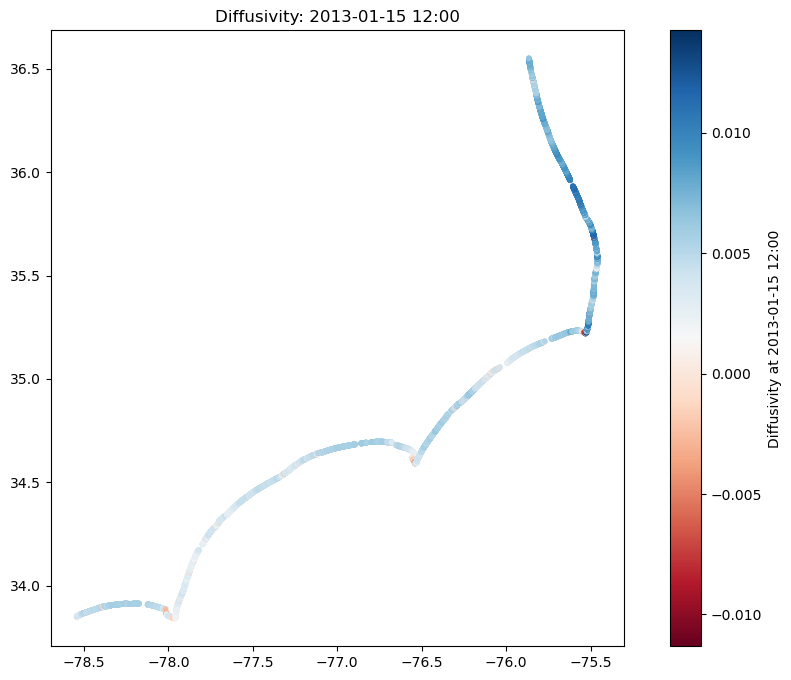

In [79]:
extracted_array = diff['dm'] 

coast_transects['snapshot_val'] = extracted_array.values.astype(float)

fig, ax = plt.subplots(figsize=(12, 8))

plot = coast_transects.set_geometry('centroid').plot(
    column='snapshot_val',
    cmap='RdBu',
    legend=False, 
    markersize=10,
    ax=ax
)
 
vmin = coast_transects['snapshot_val'].min() 
vmax = coast_transects['snapshot_val'].max()

sm = plt.cm.ScalarMappable(
    cmap='RdBu', 
    norm=plt.Normalize(vmin=vmin, vmax=vmax)
)

cbar = fig.colorbar(sm, ax=ax)
cbar.set_label(f"Diffusivity at {target_date}")

ax.set_title(f"Diffusivity: {target_date}")
plt.show()